Moving away from `blochstate`.

In [1]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import time
from scipy.linalg import eigh

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
# import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


# Inputs

In [2]:
species = "K40" # "Rb87", "K40"

# lattice parameters
# V1064Er = 5.            # 1064 lattice depth, in recoil energy
# V532Er = 3.             # 532 lattice depth, in recoil energy
# Rb kHz to Er
# V1064Er = 39.5 / 2.02781   # 25.213063
# V532Er = 0. / 8.11125    # 35.517929
# K kHz to Er
V1064Er = 39.5 / 4.4099   # 39.5
V532Er = 0 / 17.6394    # 35.517929
n0nom = 0               # peak density
# The superlattice phase that determines the relative position between 1064 and 532 lattice
# 532 lattice is fixed at 0, so changing the pase by pi for 1064 restores the original lattice
phi12, phi23 = 0., 0.
# phi12, phi23 = 0, np.pi/5
# phi12, phi23 = np.pi*2/3, -np.pi*2/3    # decorated triangular lattice
ABoffset1064nom = 0     # max 0.011585 * V1064nom / 9 / np.sqrt(3) for Rb
B1_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B1
B1_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B1
B3_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B3
B3_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B3

# Basic simulation parameters
num = 5             # size of q-momentum space we consider: (-num, num) (usually 5)
k_center = (0, 0)
bandstart = 0       # starting from 0, inclusive
bandend = 3         # inclusive
qverts_str = 'E9c.Kp/E9c.k_lw, E9c.Kp2/E9c.k_lw, E9c.Kp3/E9c.k_lw, E9c.Kp4/E9c.k_lw, E9c.Kp5/E9c.k_lw, E9c.Kp6/E9c.k_lw, E9c.Kp/E9c.k_lw'

# Initialization
## Units

In [3]:
if species == "Rb87":
    all_units_dict = E9c.all_lat_unit_Rb87
    Er_1064 = E9c.E_r1064_Rb87
    Er_532 = E9c.E_r532_Rb87
elif species == "K40":
    all_units_dict = E9c.all_lat_unit_K40
    Er_1064 = E9c.E_r1064_K40
    Er_532 = E9c.E_r532_K40
else:
    raise ValueError("Unknown species: {}".format(species))
m_unit = all_units_dict["m_unit"]
l_unit = all_units_dict["l_unit"]
E_unit = all_units_dict["E_unit"]
f_unit = all_units_dict["f_unit"]
t_unit = all_units_dict["t_unit"]

V532nom = V532Er * Er_532 / E9c.hnobar / 1e3       # in kHz (i.e. V_SI / hbar / 1e3 / 2pi), assuming that polarizability is accounted for correctly
V1064nom = V1064Er * Er_1064  / E9c.hnobar / 1e3   # Note that setting this to 0 doesn't give you a proper band structure of 532 nm lattice, since you are now
                                # considering too many plane waves that don't actually contribute.
V532 = 2 * np.pi * V532nom * 1e3 / f_unit   # 2 * np.pi because I have f = E/hbar instead of E/h as normally defined
V1064 = 2 * np.pi * V1064nom * 1e3 / f_unit
ABoffset1064 = 2 * np.pi * ABoffset1064nom * 1e3 / f_unit
n0 = n0nom * l_unit**3

In [4]:
Exp_lib = {"species": species, "units_dict": all_units_dict
        , 'V532nom': V532nom, 'V1064nom': V1064nom, 'V532': V532, 'V1064': V1064
        , 'B1_rel_int_532': B1_rel_int_532, 'B1_rel_int_1064': B1_rel_int_1064 , 'B3_rel_int_532': B3_rel_int_532, 'B3_rel_int_1064': B3_rel_int_1064
        , 'n0nom': n0nom, 'n0': n0
        , 'ABoffset1064nom': ABoffset1064nom, 'ABoffset1064': ABoffset1064
        , 'phi12': phi12, 'phi23': phi23}

size = 2 * num + 1
bandnum = bandend - bandstart + 1 # number of bands interested in
qverts_arr = eval(qverts_str)

# Real space plots

In [5]:
a_tri_um = E9c.a_sw_tri * 1e6
uc_vertices = [a_tri_um * np.array([-np.sqrt(3) * 4 / 3, 0]),
               a_tri_um * np.array([-np.sqrt(3) / 2, 1]),
               a_tri_um * np.array([np.sqrt(3) / 3, 0]),
               a_tri_um * np.array([-np.sqrt(3) / 2, -1]),]
uc_vertices.append(uc_vertices[0])

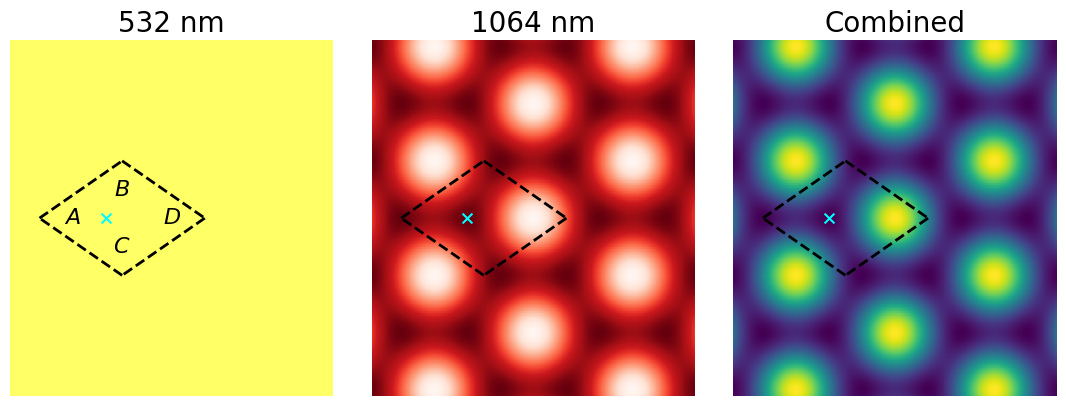

In [6]:
x_real = np.linspace(-1, 1, 500) * 1e-6
y_real = np.linspace(-1.1, 1.1, 500) * 1e-6
x_real_um = np.linspace(-1, 1, 500)
y_real_um = np.linspace(-1.1, 1.1, 500)

pos_delta = E9c.l_cell_lw * E9c.k1k * (phi12 / 2 / np.pi) + E9c.l_cell_lw * E9c.k3k * (phi23 / 2 / np.pi)
x_delta, y_delta = pos_delta # should be simple functions of phi12 and phi23
V_532_real = bsc.get_Vin(x_real, y_real, V532, B1_rel_int_532, B3_rel_int_532, 0, 0, 1)
V_1064_real = - bsc.get_Vin(x_real, y_real, V1064, B1_rel_int_1064, B3_rel_int_1064, x_delta, y_delta, 2)
V_super_real = V_532_real + V_1064_real

fig_real, (ax_532, ax_1064, ax_super) = plt.subplots(1, 3, figsize = (11, 4))
# fig_real.suptitle("Real space potential")
ax_532.set_ylabel("y (um)")
ax_1064.set_xlabel("x (um)")

for ax, V_real, ax_title, cmap_str in zip([ax_532, ax_1064, ax_super],
                                        [V_532_real, V_1064_real, V_super_real],
                                        ["532 nm", "1064 nm", "Combined"],
                                        ["summer_r", 'Reds_r', "viridis"],):
    ax.set_aspect("equal")
    im = ax.pcolormesh(x_real_um, y_real_um, V_real, cmap = cmap_str)
    # ax.scatter(0, 0, color = 'red', marker = '+', s = 50)   # origin
    ax.scatter(-a_tri_um * 2 / np.sqrt(3), 0, color = 'cyan', marker = 'x', s = 50)   # 1064 site
    
    # add unit cell
    for p1, p2 in zip(uc_vertices[:-1], uc_vertices[1:]):
        x1, y1 = p1
        x2, y2 = p2
        ax.plot([x1, x2], [y1, y2], color = "black", ls = "--", lw = 2)

    ax.set_title(ax_title, fontsize = 20)
    ax.axis("off")
    # fig_real.colorbar(im, ax = ax)

# add sublattice labels
ax_532.text(-a_tri_um * np.sqrt(3), 0, r"$A$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")
ax_532.text(-a_tri_um * np.sqrt(3) / 2, a_tri_um / 2, r"$B$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")
ax_532.text(-a_tri_um * np.sqrt(3) / 2, - a_tri_um / 2, r"$C$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")
ax_532.text(0, 0, r"$D$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")

fig_real.tight_layout()

# Finding Bloch states and band energies

Total number of points = 6517
--- 142.29024863243103 seconds ---


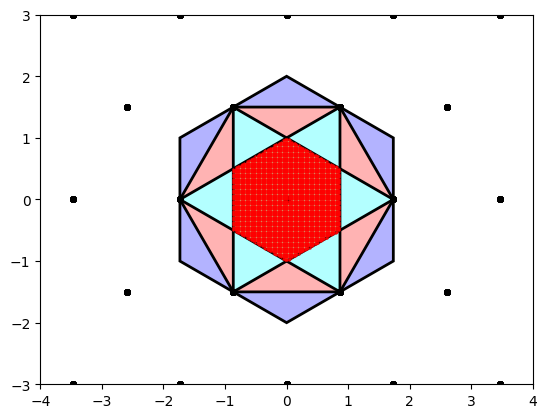

In [7]:
start_time = time.time()

# Generate qset
dq = 0.02
qsets = bsc.FindqArea(qverts_arr, dqx = dq, dqy = dq)
print("Total number of points = {0}".format(len(qsets)))
PlotBZinput = (qverts_str, qsets)
ax_BZ = bsc.PlotBZSubplot()
bsc.plot_qset(ax_BZ, qset = PlotBZinput, qset_type = "explicit")

# find non-interacting solution
e_values = np.zeros((len(qsets), bandnum), dtype = np.cdouble)
e_states = np.zeros((len(qsets), size**2, bandnum), dtype = np.cdouble)
e_states_ni = [[] for _ in range(bandnum)]  # a list of blochstate for each band

Hq_mmat, Hq_nmat, H_532, H_1064 = bsc.find_H_components(num, Exp_lib, center = k_center)
for i in range(len(qsets)):
    H = bsc.find_H(qsets[i], Exp_lib, Hq_mmat, Hq_nmat, H_532, H_1064)
    assert util.IsHermitian(H)
    e_values[i,:], e_states[i,:,:] = eigh(H, subset_by_index = (bandstart, bandend),
                                          overwrite_a = True, check_finite = False)

# Fix the gauge of eigenstates using parallel transport
e_states_fixed = bsc.fix_gauge_2d_grid(e_states, qsets, neighbor_dist = dq * 1.4)   # Using 1.5 is not good since 1.5 > sqrt(2)
for i in range(len(qsets)):
    for j, bandN in enumerate(range(bandstart, bandend + 1)):
        e_states_ni[j].append(bsc.blochstate(e_states[i,:,j], q = qsets[i], center = k_center, N = bandN, E = e_values[i,j], param = Exp_lib))
print("--- {0} seconds ---".format((time.time() - start_time)))

I always get a `ComplexWarning` when running `.astype(np.double)`, but if my own check doesn't raise a warning all is good.

In [8]:
if not np.all(np.isreal(e_values)):
    logging.warning('Complex eigenvalue detected. Imaginary parts are discarded.')
e_values = e_values.astype(np.double)

C:\Users\ken92\AppData\Local\Temp\ipykernel_37476\1078986975.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  e_values = e_values.astype(np.double)


So far all the lists are organized in 1D, in the order of qsets. To plot things using e.g. pcolormesh(), the values need to be reorganized into a 2D grid that knows about the relative position between q points. This doesn't matter if each object is plotted independently, e.g. using quiver().

In [9]:
# Reconstruct grid for pcolormesh
qx_qsets = qsets[:, 0]
qy_qsets = qsets[:, 1]
qx_vals = np.unique(qx_qsets)
qy_vals = np.unique(qy_qsets)
nx = len(qx_vals)
ny = len(qy_vals)

# Map from coordinate to grid index
qx_to_i = {val: i for i, val in enumerate(qx_vals)}
qy_to_j = {val: j for j, val in enumerate(qy_vals)}

def to_qxy_grid(arr, fill_value = np.nan):
    grid = np.full((ny, nx), fill_value)
    for k in range(len(arr)):
        i = qx_to_i[qx_qsets[k]]
        j = qy_to_j[qy_qsets[k]]
        grid[j, i] = arr[k]     # row = y, col = x
    return grid

In [10]:
E9c.a_lw_hex

np.float64(4.095337909451746e-07)

## Band structure plot

Text(0.5, 0.92, '$V_{532}$ = 0.000 kHz ($0.0\\ E_r$), V1064 = 39.500 kHz ($8.957119209052358\\ E_r$)\nAB offset = 0.000 kHz, $\\phi_{12} = 0.000$, $\\phi_{23} = 0.000$')

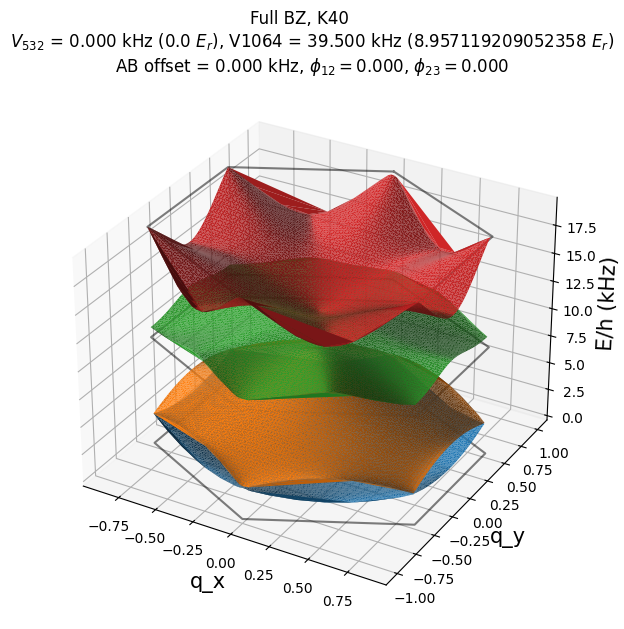

In [11]:
E2kHz = E_unit / E9c.hnobar / 1e3 # conversion factor from natural units to kHz
E_lowest = np.min(e_values)
E_kHz_offset = (e_values - E_lowest) * E2kHz
E_kHz_highest = np.max(E_kHz_offset)
fig_E = plt.figure(0, figsize=(10,7))
fig_E.clf()
fig_E.suptitle(f"Full BZ, {species}")

ax_E = fig_E.add_subplot(111, projection = '3d')
# Add BZ boundary
bz1qx, bz1qy = [q[0] for q in E9c.BZ1_vertices], [q[1] for q in E9c.BZ1_vertices]
for i in range(3):
    ax_E.plot(bz1qx, bz1qy, np.ones_like(bz1qx) * E_kHz_highest * i / 2, '-k', alpha = 0.5)
for i in range(bandnum):
    ax_E.plot_trisurf(qsets[:, 0], qsets[:, 1], E_kHz_offset[:, i]) # TODO: try plotly
ax_E.set_xlabel('q_x', fontsize = 15)
ax_E.set_ylabel('q_y', fontsize = 15)
ax_E.set_zlabel('E/h (kHz)', fontsize = 15)

ax_E.set_title((rf'$V_{{532}}$ = {V532nom:.3f} kHz (${V532Er}\ E_r$), V1064 = {V1064nom:.3f} kHz (${V1064Er}\ E_r$)'
                '\n'
                rf'AB offset = {float(ABoffset1064nom):.3f} kHz, $\phi_{{12}} = {phi12:.3f}$, $\phi_{{23}} = {phi23:.3f}$'))

## Position of gaps at a specific frequency
The value of `alpha` is chosen to be a Gaussian centered around `f_kHz_gap_target` in gap energy (in frequency units).

In [12]:
gap_band1 = [0]
gap_band2 = [1]
f_kHz_gap_target = 3
f_kHz_gap_width = 1.
color_gap = ["r", "b"]

Text(0.5, 1.0, 'gap = 3.00$\\pm$1.0 kHz')

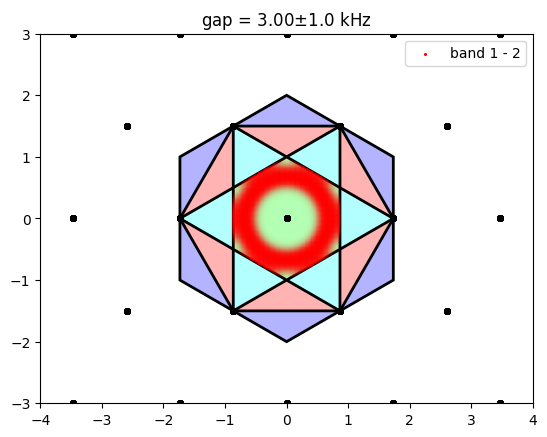

In [13]:
ax_gap = bsc.PlotBZSubplot()
for b1, b2, c in zip(gap_band1, gap_band2, color_gap):
    f_kHz_gap = E_kHz_offset[:, b2] - E_kHz_offset[:, b1]
    alpha_mask_gap = util.Gaussian_1D(f_kHz_gap, f_kHz_gap_width, f_kHz_gap_target, normalization = 'max1')
    bsc.plot_qset(ax_gap, qset = PlotBZinput, qset_type = "explicit", qset_kwargs = {"alpha": alpha_mask_gap, "color": c})
    ax_gap.scatter(10, 10, s = 1.5, color = c, label = f"band {b1 + 1} - {b2 + 1}") # add points outside of the plot for legend purposes
ax_gap.legend()
ax_gap.set_title((f"gap = {f_kHz_gap_target:.2f}" r"$\pm$"
                  f"{f_kHz_gap_width} kHz"))
# r_out = 24/27.71
# util.fill_annulus(ax_gap, (0, 0), 2/3 * r_out, r_out, alpha = 0.5)

# Interband Berry conections
I calculate all the connections within the given range of bands.
## Finding $A_{mn}$

In [14]:
# For example, A_01(q = qsets[i_q]) = inter_Berry_conns[i_q, 0, 1, :]
# To avoidA_10(q = qsets[i_q]) = inter_Berry_conns[i_q, 0, 1, :]
inter_Berry_conns = np.zeros((len(qsets), bandnum, bandnum, 2), dtype = np.float128)

# e_states_fixed = bsc.fix_gauge_2d_grid(e_states, qsets, n_q_init = 0, neighbor_dist = dq * 1.2)    # Uncomment if you want to re-fix the gauge
for i in range(len(qsets)):
    for i_lower in range(bandnum):
        for i_higher in range(i_lower + 1, bandnum):
            psi1, psi2 = e_states_fixed[i, :, i_lower], e_states_fixed[i, :, i_higher]
            E12 = e_values[i, i_higher] - e_values[i, i_lower]  # Hellman-Feynman doesn't work for intraband connection because E12 = 0
            inter_Berry_conns[i, i_lower, i_higher, :] = bsc.find_inter_Berry_conn(qsets[i], psi1, psi2, E12, Exp_lib, Hq_mmat, Hq_nmat)

inter_Berry_conns_mag = np.linalg.norm(inter_Berry_conns, axis = 3)

C:\Users\ken92\AppData\Local\Temp\ipykernel_37476\1853497716.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  inter_Berry_conns[i, i_lower, i_higher, :] = bsc.find_inter_Berry_conn(qsets[i], psi1, psi2, E12, Exp_lib, Hq_mmat, Hq_nmat)


## Derived quantities (change inputs here)
e.g. Matrix element of shaking

In [15]:
i_Berry = (0, 3)            # The bands between which the A_mn is plotted
str_circ_PM = None           # "L" or "R" for left- / right-handed shaking, linear otherwise
# str_circ_PM = "L"
theta_lin_PM = np.pi / 2    # Angle of shaking
unit_conn = "a0_1064"       # unit used for plotting the connection
Ma_exp = 0.3                # Modulation depth, only used for "Rabi_Hz"

In [16]:
vec_PM = np.array([np.cos(theta_lin_PM), np.sin(theta_lin_PM)])
if str_circ_PM == "L":
    vec_PM = np.array([1j, 1]) / np.sqrt(2)
elif str_circ_PM == "R":
    vec_PM = np.array([1j, -1]) / np.sqrt(2)

unit_conv = 1.
if unit_conn == "Rabi_Hz":
    unit_conv = l_unit * (E9c.E_r1064_K40 / E9c.hnobar) / E9c.a_sw_tri * (np.pi**2 / 9) * Ma_exp
elif unit_conn == "a0_1064":
    unit_conv = l_unit / E9c.a_lw_hex

In [17]:
A_Berry = inter_Berry_conns[:, *i_Berry, :] # Interband Berry connection of the selected bands
A_Berry_x = inter_Berry_conns[:, *i_Berry, 0]
A_Berry_y = inter_Berry_conns[:, *i_Berry, 1]
A_mag = inter_Berry_conns_mag[:, *i_Berry]  # Magnitude of A_Berry
A_plot = A_Berry / A_mag[:, np.newaxis]     # Normalized A_Berry for the direction plot
ME2_Fermi = np.abs(A_Berry @ vec_PM)**2     # Proportional to matrix element squared
f_kHz_gap_Berry = E_kHz_offset[:, i_Berry[1]] - E_kHz_offset[:, i_Berry[0]]

A_mag = np.nan_to_num(A_mag, nan = 0., posinf = 1.)
ME2_Fermi = np.nan_to_num(ME2_Fermi, nan = 0., posinf = 1.)

# 2D arrays
A_x_grid = to_qxy_grid(A_Berry_x)
A_y_grid = to_qxy_grid(A_Berry_y)
A_mag_grid = to_qxy_grid(A_mag)
ME2_Fermi_grid = to_qxy_grid(ME2_Fermi)
f_kHz_gap_Berry_grid = to_qxy_grid(f_kHz_gap_Berry)

## Plots

In [18]:
alpha_pwr = 1/3
crange = 9
bool_look_for_flips = False
bool_plot_log = False

In [19]:
if bool_look_for_flips:
    flip_indices, flip_angles = bsc.find_connection_sign_flips(
        qsets, A_Berry,
        neighbor_dist = 2. * dq,            # 1.5 * dq misses a few points
        G_vecs = [E9c.g1g, E9c.g2g],
        A_min = np.percentile(A_mag, 2),    # Didn't play around with this a lot
        threshold_wrap = 0.97,
        tol = 0.2                           # 0.1 is too small
    )

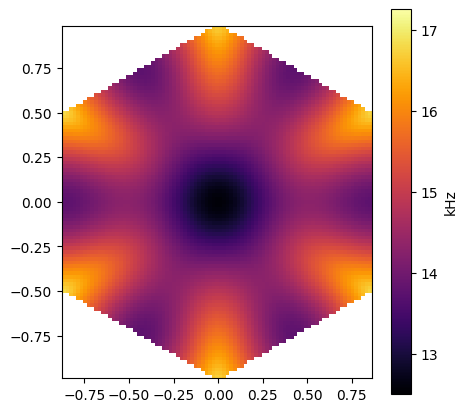

In [20]:
fig_Berry_gap, ax_Berry_gap = plt.subplots(1, 1, figsize=(5, 5))
QX, QY = np.meshgrid(qx_vals, qy_vals)
pcm = ax_Berry_gap.pcolormesh(
                QX, QY, f_kHz_gap_Berry_grid,
                shading='auto',
                cmap='inferno', clim = [12.5, 17.25]
            )
fig_Berry_gap.colorbar(pcm, ax = ax_Berry_gap, label = "kHz")
ax_Berry_gap.set_aspect(1)

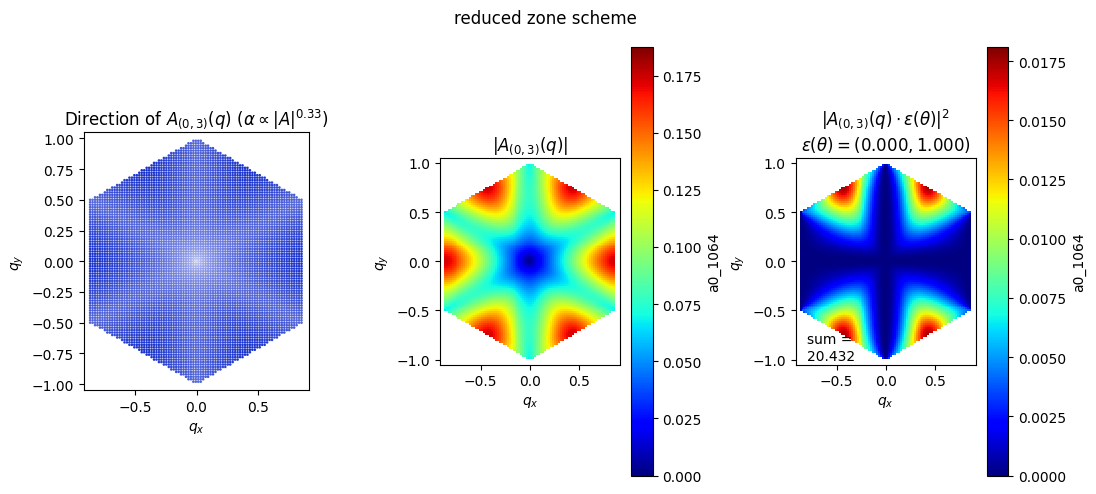

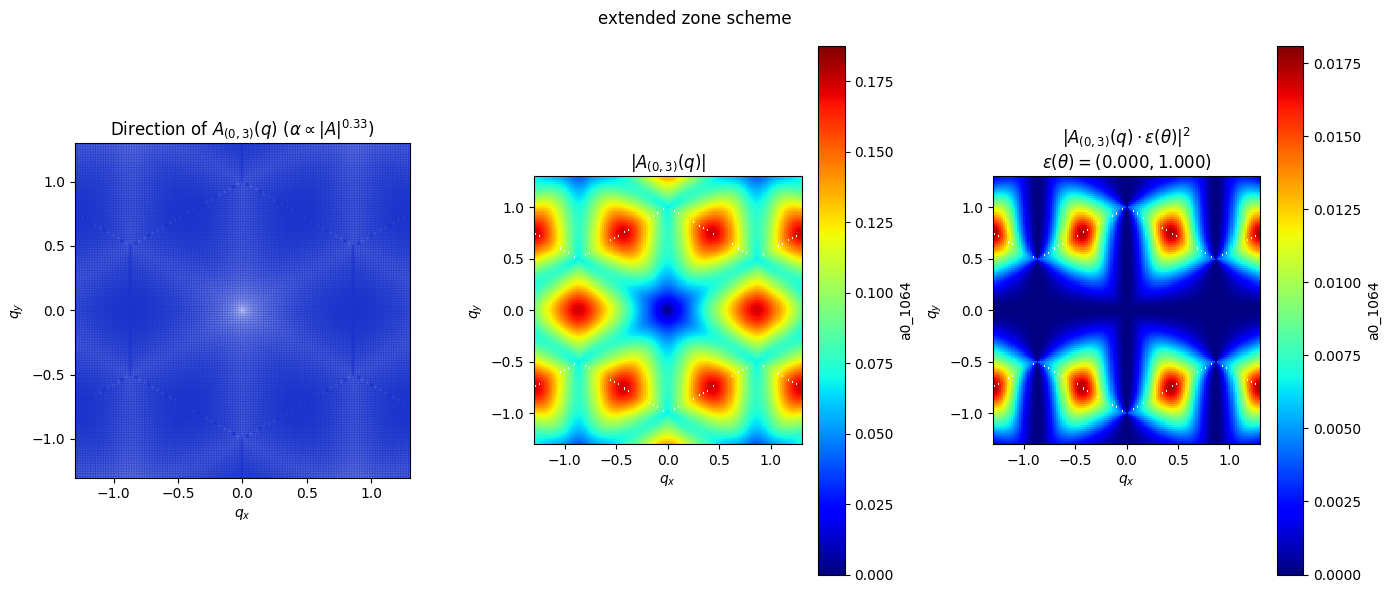

In [21]:
# Visualize A_01(q) as a vector field over the BZ
fig_Berry_reduced_BZ, axes_Berry_reduced_BZ = plt.subplots(1, 3, figsize=(11, 5))
fig_Berry_extended_BZ, axes_Berry_extended_BZ = plt.subplots(1, 3, figsize=(14, 6))

# Normalize magnitudes into [0,1] for alpha
A_mag_finite = A_mag[np.isfinite(A_mag)]
if np.nanmax(A_mag_finite) > 0:
    # Using A_mag_finite.max() often fails due to divergence at K; similar for the color range in the amplitude plot
    alpha_vals = np.nan_to_num(A_mag / np.nanpercentile(A_mag_finite, 99.5), nan = 0., posinf = 1., neginf = 1.)
    alpha_vals[alpha_vals > 1.] = 1.
else:
    alpha_vals = np.zeros_like(A_mag)

# Vector field plots
# Build RGBA colors with alpha = amplitude
base_color = (0.1, 0.2, 0.8)  # e.g. blue-ish
colors_rgba = np.zeros((len(A_mag), 4))
colors_rgba[:, 0] = base_color[0]
colors_rgba[:, 1] = base_color[1]
colors_rgba[:, 2] = base_color[2]
colors_rgba[:, 3] = alpha_vals**alpha_pwr

quiver_scale = 0.05 / dq
for ax, range_g1g, range_g2g in zip(
    [axes_Berry_reduced_BZ[0], axes_Berry_extended_BZ[0]],
    [[0], [-1, 0, 1]],  # Plotting copies of the same plot integer number of reciprocal lattice vectors away
    [[0], [-1, 0, 1]],  # (Just for the extended zone scheme)
):
    for idx_g1g in range_g1g:
        for idx_g2g in range_g2g:
            qxg = qx_qsets + idx_g1g * E9c.g1g[0] + idx_g2g * E9c.g2g[0]
            qyg = qy_qsets + idx_g1g * E9c.g1g[1] + idx_g2g * E9c.g2g[1]
            ax.quiver(
                qxg, qyg,
                A_plot[:, 0], A_plot[:, 1],
                color = colors_rgba,
                angles = 'xy', scale_units = 'xy', scale = 20 * quiver_scale,
                width = 0.005 * quiver_scale
            )
    ax.set_title(rf"Direction of $A_{{{i_Berry}}}(q)$ ($\alpha \propto |A|^{{{alpha_pwr:.2f}}}$)")

if bool_look_for_flips and flip_indices:
    flip_qx = qx_qsets[flip_indices]
    flip_qy = qy_qsets[flip_indices]
    axes_Berry_extended_BZ[0].scatter(flip_qx, flip_qy, 
                   s=100, marker='x', color='orange', linewidth=2,
                   label='Potential sign flips', zorder=5)
    axes_Berry_extended_BZ[0].legend()

# Amplitude plots (|A| and matrix element squared)
# Make 2D coordinate grids for pcolormesh
for ax, fig, data, range_g1g, range_g2g in zip(
    [axes_Berry_reduced_BZ[1], axes_Berry_extended_BZ[1], axes_Berry_reduced_BZ[2], axes_Berry_extended_BZ[2]],
    [fig_Berry_reduced_BZ, fig_Berry_extended_BZ, fig_Berry_reduced_BZ, fig_Berry_extended_BZ],
    # [abs(A_x_grid), abs(A_x_grid), abs(A_y_grid), abs(A_y_grid)], # dirty code for comparing with Malte, delete when not used
    [A_mag_grid, A_mag_grid, ME2_Fermi_grid, ME2_Fermi_grid],
    [[0], [-1, 0, 1], [0], [-1, 0, 1]],
    [[0], [-1, 0, 1], [0], [-1, 0, 1]],
):
    dmid = np.nanpercentile(data, 50)
    d99 = np.nanpercentile(data, 99)
    if bool_plot_log:
        plt_data = np.log(data)
        clim = (dmid - crange, dmid + crange)
    else:
        plt_data = data
        clim = (0, d99 * 1.1)
        # clim = (0, 300)
    clim = np.asarray(clim) * unit_conv
    
    for idx_g1g in range_g1g:
        for idx_g2g in range_g2g:
            QX, QY = np.meshgrid(qx_vals + idx_g1g * E9c.g1g[0] + idx_g2g * E9c.g2g[0],
                                 qy_vals + idx_g1g * E9c.g1g[1] + idx_g2g * E9c.g2g[1], indexing='xy')
            pcm = ax.pcolormesh(
                QX, QY, plt_data * unit_conv,
                shading='auto',
                cmap='jet', clim = clim
            )
    fig.colorbar(pcm, ax = ax, label = unit_conn)

t_prefix = ""
if bool_plot_log: t_prefix = "log"
pol_suffix = "\n" + rf"$\epsilon(\theta) = ({vec_PM[0]:.3f}, {vec_PM[1]:.3f})$"
axes_Berry_reduced_BZ[1].set_title(t_prefix + rf"$|A_{{{i_Berry}}}(q)|$")
axes_Berry_reduced_BZ[2].set_title(t_prefix + rf"$|A_{{{i_Berry}}}(q) \cdot \epsilon(\theta)|^2$" + pol_suffix)
axes_Berry_reduced_BZ[2].text(-0.8, -1, f"sum = \n{np.nansum(ME2_Fermi_grid):.3f}")
axes_Berry_extended_BZ[1].set_title(t_prefix + rf"$|A_{{{i_Berry}}}(q)|$")
axes_Berry_extended_BZ[2].set_title(t_prefix + rf"$|A_{{{i_Berry}}}(q) \cdot \epsilon(\theta)|^2$" + pol_suffix)

# Repetitive stuff
for axes, xlim, ylim in zip(
    [axes_Berry_reduced_BZ, axes_Berry_extended_BZ],
    [(-np.sqrt(3)/2 - 0.05, np.sqrt(3)/2 + 0.05), (-1.3, 1.3)],
    [(-1.05, 1.05), (-1.3, 1.3)],):
        for ax in axes:
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)
            ax.set_xlabel(r"$q_x$")
            ax.set_ylabel(r"$q_y$")
            ax.set_aspect('equal')

fig_Berry_reduced_BZ.suptitle("reduced zone scheme")
fig_Berry_extended_BZ.suptitle("extended zone scheme")
fig_Berry_reduced_BZ.tight_layout()
fig_Berry_extended_BZ.tight_layout()

In [22]:
E9c.a_sw_tri * E9c.hnobar * 2 * np.pi / 4 / E9c.m_K40 / E9c.lambda_lw**3 * 0.3 / 15e3

0.09235988059558349

# Figure 2
Theory plot of the excitation ratio.


## Inputs

In [23]:
thetas_lin_PM_fig2 = np.array([-120, -80, -40, 0]) * np.pi / 180    # Angle of shaking
# thetas_lin_PM_fig2 = np.array([-160, -140, -120, -100, -80, -60, -40, -20, 0]) * np.pi / 180    # All angles of shaking
f_kHz_gap_target_fig2 = 3
f_kHz_gap_width_fig2 = 2.0  # this should be 2 / t_PM
f_kHz_gap_01 = E_kHz_offset[:, 1] - E_kHz_offset[:, 0]

# Make sure the inputs below are the same as the ones used in the actual data analysis
r_ring_data_analysis = np.array([18, 24])   # The radius of the ring used in data analysis
y_BZ3edge = 48.                             # Position of the 3rd BZ edge

## Calculations
I assume no coherence between the lower and upper states, which is justified in the paper. The population in the first BZ then gets contribution from both lower and upper band states, although the upper band state is a very small correction.

In [124]:
# Simple derived numbers
N_thetas_fig2 = len(thetas_lin_PM_fig2)
px_qK = y_BZ3edge * 2 / 3   # qK in units of camera pixels
qK_ring = r_ring_data_analysis / px_qK
rq_circ = qK_ring.mean()
print(qK_ring)
print(rq_circ)

# Population in the 0th order peak
n0 = 0
n1 = 1
mn00_band0 = np.array([abs(psi.mnasindex(0, 0))**2 for psi in e_states_ni[n0]])
mn00_band1 = np.array([abs(psi.mnasindex(0, 0))**2 for psi in e_states_ni[n1]])
mn00_band0_grid = to_qxy_grid(mn00_band0)
mn00_band1_grid = to_qxy_grid(mn00_band1)

# excitation_rate_fig2 = util.Gaussian_1D(f_kHz_gap_01, f_kHz_gap_width_fig2, f_kHz_gap_target_fig2, normalization = 'max1')
excitation_rate_fig2 = util.sinc((f_kHz_gap_01 - f_kHz_gap_target_fig2) / f_kHz_gap_width_fig2)**2
# excitation_rate_fig2 = 1

A_Berry = inter_Berry_conns[:, 0, 1, :] # Interband Berry connection of the selected bands
A_mag = inter_Berry_conns_mag[:, 0, 1]  # Magnitude of A_Berry
A_mag = np.nan_to_num(A_mag, nan = 0., posinf = 1.)


[0.5625 0.75  ]
0.65625


## Helper plots

### Populations in the 0th order peak in band 1 and 4

0.8365142858390389
0.6166699041333691
155.63199588868343


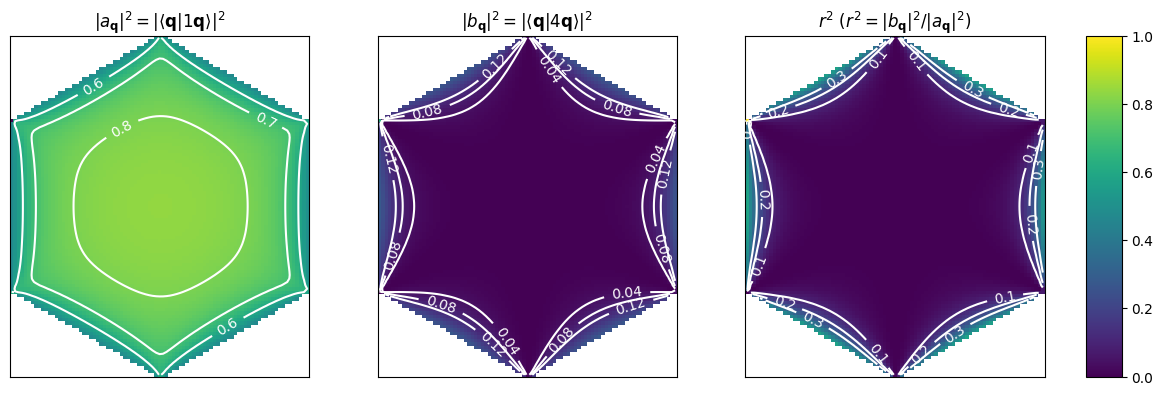

In [125]:
fig_mn00, axes_mn00 = plt.subplots(1, 4, figsize = (12, 4), width_ratios = [10, 10, 10, 1])

QX, QY = np.meshgrid(qx_vals, qy_vals)
max_mn00 = np.nanmax(np.concat([mn00_band0_grid, mn00_band1_grid]))
r_amplify = 1
mainttl_r2 = rf"${r_amplify} r^2$"
if r_amplify == 1: mainttl_r2 = r"$r^2$"

for ax, mn00, cntr_lvls, title in zip(
        axes_mn00,
        [mn00_band0_grid, mn00_band1_grid, r_amplify * (mn00_band1_grid/mn00_band0_grid)],
        [[0.6, 0.7, 0.8], [0.04, 0.08, 0.12], [0.1, 0.2, 0.3]],
        [r"$|a_{\mathbf{q}}|^2 = |\langle \mathbf{q} | 1 \mathbf{q} \rangle|^2$",
        r"$|b_{\mathbf{q}}|^2 = |\langle \mathbf{q} | 4 \mathbf{q} \rangle|^2$",
        mainttl_r2 + " ($r^2 = |b_{\mathbf{q}}|^2 / |a_{\mathbf{q}}|^2$)"]):
    msh = ax.pcolormesh(QX, QY, mn00, clim = (0, 1), rasterized = True)
    cntr = ax.contour(QX, QY, mn00, colors = "white", linestyles = "solid",# levels = 3)
                      levels = cntr_lvls)
    ax.clabel(cntr, inline = True)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    print(np.nanmax(mn00))

fig_mn00.colorbar(msh, cax = axes_mn00[-1])#, ticks = [0, 1])
fig_mn00.tight_layout()
figpath = Path(r"C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\band_spectroscopy\PRL submission\reply",
                 f"fig_r{n0+1}{n1+1}.pdf")
fig_mn00.savefig(figpath, format = "pdf", facecolor = "none", dpi = 300)#, bbox_inches = 'tight')

## Actual fig.2
Currently I use
* `origin_fig2 = "lower"`
* `bool_plot_log = True`

in the actual figure.

In [126]:
# Placeholder values
max_excitation = 0.6    # Maximum population excited - this should be extracted from the experiment!
# In my python code convention, the normal oritation (positive y points up) corresponds to
# lab convention (i.e. positive y points down, using default imshow())
origin_fig2 = "lower"

In [127]:
sgn_y_conv = 1
if origin_fig2 == "lower":
    sgn_y_conv = -1

clim_fig2c = (0, max_excitation)
if bool_plot_log:
    clim_fig2c = (-20, 0)

Using max_excitation = 0.6


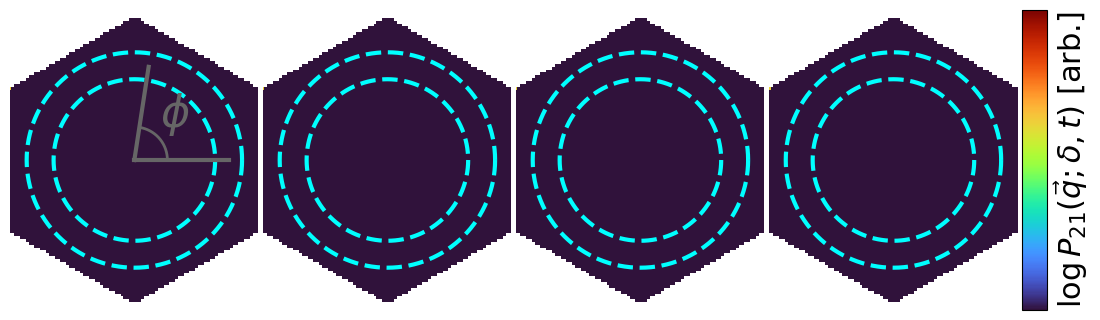

In [128]:
print(f"Using max_excitation = {max_excitation}")
# Visualize A_01(q) as a vector field over the BZ
fig2, axes2 = plt.subplots(1, N_thetas_fig2 + 1, figsize = (N_thetas_fig2 * 2.7, 3.), width_ratios = [10] * N_thetas_fig2 + [1])

QX, QY = np.meshgrid(qx_vals, qy_vals)
for i_theta, (ax, theta) in enumerate(zip(axes2, thetas_lin_PM_fig2)):
    vec_PM = np.array([np.cos(theta), np.sin(theta)])

    ME2_Fermi = np.abs(A_Berry @ vec_PM)**2     # Proportional to matrix element squared
    max_ME2 = np.nanmax(ME2_Fermi[np.isfinite(ME2_Fermi)])

    ME2_Fermi = np.nan_to_num(ME2_Fermi, nan = 0., posinf = max_ME2, neginf = 0.)
    excitation_ratio_fig2 = ME2_Fermi * excitation_rate_fig2
    max_ratio = np.nanmax(excitation_ratio_fig2[np.isfinite(excitation_ratio_fig2)])

    excitation_ratio_fig2 = excitation_ratio_fig2 / max_ratio * max_excitation
    delta_mn00_fig2 = excitation_ratio_fig2 * (mn00_band0 - mn00_band1)
    delta_mn00_fig2_grid = to_qxy_grid(delta_mn00_fig2)

    data_fig2 = delta_mn00_fig2_grid
    if bool_plot_log: data_fig2 = np.log(delta_mn00_fig2_grid)
    pcm = ax.pcolormesh(
                QX, QY, data_fig2,
                shading='auto',
                cmap='turbo', clim = clim_fig2c
            )
    util.draw_circle(ax, center = np.array([0, 0]), radius = qK_ring[0], color = "cyan", ls = '--', lw = 3)
    util.draw_circle(ax, center = np.array([0, 0]), radius = qK_ring[1], color = "cyan", ls = '--', lw = 3)

    ax.set_xlim(-np.sqrt(3) / 2., np.sqrt(3) / 2. + 0.03)
    ax.set_ylim(-1.02 * sgn_y_conv, 1.02 * sgn_y_conv)
    ax.axis("off")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

# Add definition of \phi
color_phi_ex = "#666666"
phi_ex = - np.pi * 9 / 20 - 0.005 # remember that the y-axis is flipped
phi_ex_pt = rq_circ * np.array([np.cos(phi_ex), np.sin(phi_ex)])
axes2[0].plot([0, rq_circ], [0, 0], color = color_phi_ex,
              linewidth = 3, linestyle = "-")
axes2[0].plot([0, phi_ex_pt[0]], [0, phi_ex_pt[1]], color = color_phi_ex,
              linewidth = 3, linestyle = "-")
util.draw_circle(axes2[0], center = np.array([0, 0]), radius = 0.23, theta_range = (0, phi_ex),
                 close_circle = False, color = color_phi_ex, ls = '-', lw = 2)
axes2[0].text(0.18, -0.23, r"$\phi$", fontsize = 32, color = color_phi_ex)

cbar_fig2c = fig2.colorbar(pcm, cax = axes2[-1], ticks = [])
cbar_fig2c.set_label(r"$\log P_{21}(\vec{q}; \delta, t)$ [arb.]", fontsize = 22)
fig2.tight_layout(pad = 0, h_pad = 0, w_pad = 0)

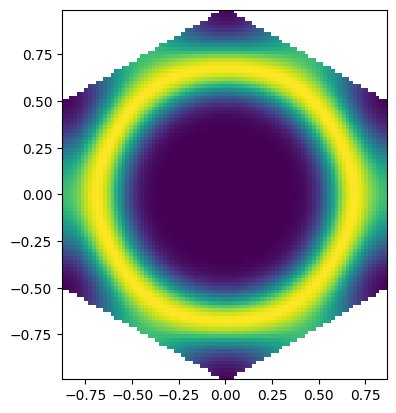

In [129]:
alpha_grid = np.full((ny, nx), np.nan)
for k in range(len(A_mag)):
    i = qx_to_i[qx_qsets[k]]
    j = qy_to_j[qy_qsets[k]]
    alpha_grid[j, i] = alpha_mask_gap[k]

fig, ax = plt.subplots(1,1)
ax.pcolormesh(
                QX, QY, alpha_grid,
                shading='auto',
                cmap='viridis', clim = (0, 1)
            )
ax.set_aspect('equal')

## Quantum metric tensor (ignore for now)

In [130]:
bool_find_QMT = False

In [131]:
def find_q_geo_tensor(n_q, n_band, Exp_lib, q_list, E_list, psi_list, Hq_mmat, Hq_nmat, component = 'xx'):
    """Find the quantum geometric tensor for a given Bloch state psi."""
    q = q_list[n_q]
    psin = psi_list[n_q, :, n_band]
    En = E_list[n_q, n_band]
    dH1 = bsc.find_del_q_of_H(q, Exp_lib, Hq_mmat, Hq_nmat, direction = component[0])
    dH2 = bsc.find_del_q_of_H(q, Exp_lib, Hq_mmat, Hq_nmat, direction = component[1])
    qgt = 0j
    for m_band in range(E_list.shape[1]):
        if m_band == n_band:
            continue
        psim = psi_list[n_q, :, m_band]
        Em = E_list[n_q, m_band]
        qgt += psim.conj() @ dH1 @ psin * psin.conj() @ dH2 @ psim / (Em - En)**2
    if not util.IsHermitian(qgt):
        logging.warning(f"Quantum geometric tensor for n_band {n_band}, n_q {n_q} is not Hermitian")
    return qgt

In [132]:
if bool_find_QMT:
    qgts_xx = np.zeros((len(qsets), bandnum), dtype = np.cdouble)
    for i in range(len(qsets)):
        for j in range(bandnum):
            qgts_xx[i, j] = find_q_geo_tensor(i, j, Exp_lib, qsets, e_values, e_states, Hq_mmat, Hq_nmat)
    qmts_xx = np.real(qgts_xx)                # quantum metric tensor
    berry_curvs_xx = - 2 * np.imag(qgts_xx)   # Berry curvature

    fig_qgt = plt.figure(2, figsize=(10,7))
    fig_qgt.clf()
    ax_qgt = fig_qgt.add_subplot(111)
    ax_qgt.set_title('Quantum geometric tensor')
    ax_qgt.plot(xq, qmts_xx[:, 2], label = 'qmts_00')